# Query understanding for semantic search on Qdrant: Jev, confidence gates, and a Netflix-style router

A shopper types **"king poster bed"**. Hybrid search (dense + BM25) matches the words, but it has no idea the shopper wants something from *Furniture / Bedroom Furniture*, so products that share the words but not the intent compete for the top spots.

`jevqu` asks Jev, TypeSafe's decision model, which catalog categories the query is about, then lets Jev's confidence decide what happens in Qdrant:

| confidence P | what jevqu does |
|---|---|
| P ≥ 0.9 | hard payload filter; if too few hits come back, the page is refilled from the unfiltered ranking |
| 0.6 ≤ P < 0.9 | score boost through a Qdrant formula query |
| P < 0.6 | nothing: results are identical to plain hybrid search |

This notebook measures that on **WANDS**, Wayfair's product-search benchmark (43k products, 480 queries, human relevance labels), and answers four questions:

1. Does gated query understanding beat plain hybrid search on nDCG@10?
2. How much does a hard filter cost when the guess is wrong, and does gating avoid that cost?
3. Where should the filter threshold sit for this collection?
4. How does it compare with Netflix's approach to query understanding for semantic search, which routes each query to a trie, a compact BERT model or an LLM?

## Which classifier runs

- **With `OPENROUTER_API_KEY` set** (in the environment or in a `.env` file at the repo root), Jev (`typesafe/jev-1.13`) classifies every point and every query through OpenRouter's System One endpoint. Jev is a decision model, not a chat model: each request is one state plus all of a point's class questions, judged together, and the answer is a probability per question, back in about half a second. Only input tokens are billed (a 450-token request costs about $0.00002). The notebook labels a small pilot batch first, reads the cost from each response, and stops if the extrapolated total exceeds `JEVQU_MAX_USD` (default $10). Answers are cached in `.jev_cache/`, so reruns cost nothing.
- **Without a key**, a simulated classifier stands in so the notebook runs offline. Points get their WANDS catalog category, with 2% relabeled at random. Queries get a calibrated guess: confidence P is drawn uniformly from [0.5, 1], and the guess is right with probability P.

Section 8 compares the classifier with simulated classifiers of known quality either way. Calibration does not transfer across collections, so check the calibration table in section 7 before trusting the thresholds. Relevance judgments are WANDS's human "Exact" labels in all cases.

In [1]:
import csv, dataclasses, os, random, re, sys, tempfile, time, urllib.request, warnings
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found")        # tqdm without ipywidgets
warnings.filterwarnings("ignore", message="Payload indexes have no effect")  # in-memory Qdrant only

import matplotlib.pyplot as plt
import numpy as np
from fastembed import SparseTextEmbedding, TextEmbedding
from IPython.display import Markdown, display
from qdrant_client import QdrantClient, models
from sklearn.linear_model import LogisticRegression

ROOT = Path.cwd() if (Path.cwd() / "jevqu").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
for line in (ROOT / ".env").read_text().splitlines() if (ROOT / ".env").exists() else []:
    key, _, value = line.partition("=")
    if key.strip() and not key.lstrip().startswith("#"):
        os.environ.setdefault(key.strip(), value.strip().strip("'\""))

from jevqu import JEV_MODEL
from jevqu.api import create_query_understanding, set_query_understanding, understand_query, upload_points
from jevqu.evalstark import recall_loss_curve, report_markdown
from jevqu.metrics import ndcg_at_k, paired_bootstrap, recall_at_k
from jevqu.jev import Jev
from jevqu.qquery import build_filter, build_formula, run
from jevqu.schema import ClassDef, Taxonomy, Thresholds, Understanding
from jevqu.store import load_taxonomy

SEED = 0
N_QUERIES = 200           # evaluation queries (of the 379 WANDS queries with an exact match)
N_PRODUCTS = 10_000       # collection: exact matches of those queries plus random distractors
MAX_EXACT_PER_QUERY = 30  # keeps a few very broad queries from filling the collection
CONF_LOW = 0.5            # simulated classifier only: confidence ~ U(CONF_LOW, 1)
USE_JEV = bool(os.environ.get("OPENROUTER_API_KEY"))
MAX_USD = float(os.environ.get("JEVQU_MAX_USD", "10"))  # labeling stops before spending more than this
WORKERS = 8               # parallel Jev requests (stays under Jev's ~1,200 requests a minute)
PILOT = 25                # points labeled first to price the full run
DATA = ROOT / "data" / "wands"
COLLECTION = "wands"
CLASSIFIER = JEV_MODEL if USE_JEV else "simulated"
ADV = "Jev" if USE_JEV else "simulated classifier"   # the classifier behind jevqu in this run
print("classifier:", f"Jev ({JEV_MODEL}) on OpenRouter" if USE_JEV else "simulated (no OPENROUTER_API_KEY)")

classifier: simulated (no OPENROUTER_API_KEY)


## 1. Load WANDS

Three tab-separated files from the [WANDS repository](https://github.com/wayfair/WANDS): products, queries, and query-product judgments (Exact / Partial / Irrelevant). The first run downloads about 90 MB into `data/wands/`.

In [2]:
BASE = "https://raw.githubusercontent.com/wayfair/WANDS/main/dataset/"
DATA.mkdir(parents=True, exist_ok=True)
csv.field_size_limit(sys.maxsize)

def load(name):
    path = DATA / f"{name}.csv"
    if not path.exists():
        urllib.request.urlretrieve(BASE + path.name, path)
    with open(path, newline="") as f:
        return list(csv.DictReader(f, delimiter="\t"))

products, queries, labels = load("product"), load("query"), load("label")
print(f"{len(products):,} products, {len(queries)} queries, {len(labels):,} judgments")

42,994 products, 480 queries, 233,448 judgments


## 2. A taxonomy from the catalog tree

Every WANDS product sits in a category path such as *Furniture / Bedroom Furniture / Beds & Headboards / Beds*. The first level becomes the parent classes and the second level the child classes. jevqu asks about all parents in one packed request and asks about children only under confident parents.

The appendix shows the other route: with an OpenRouter key, jevqu induces a taxonomy from the data and keeps only classes that improve retrieval.

In [3]:
def slug(s):
    return re.sub(r"[^a-z0-9]+", "-", s.lower()).strip("-")

path_of = {p["product_id"]: p["category hierarchy"].split(" / ") for p in products if p["category hierarchy"].strip()}
top = sorted({x[0] for x in path_of.values()})
second = sorted({(x[0], x[1]) for x in path_of.values() if len(x) > 1})
classes = [ClassDef(slug(a), a, f"The product belongs in the '{a}' department of a home-goods store",
                    "Products from any other department") for a in top]
classes += [ClassDef(slug(f"{a} {b}"), b, f"The product belongs in '{a} / {b}'",
                     f"{a} products of another kind, or products outside {a}", parent=slug(a)) for a, b in second]
tax = Taxonomy("wands-categories-v1", CLASSIFIER, classes, facets=[], thresholds=Thresholds())
label_of = {slug(a): a for a in top} | {slug(f"{a} {b}"): f"{a} / {b}" for a, b in second}

def gold_classes(pid):  # (parent id, child id or None) from the catalog, or None for uncategorized products
    x = path_of.get(pid)
    return None if x is None else (slug(x[0]), slug(f"{x[0]} {x[1]}") if len(x) > 1 else None)

print(f"{len(tax.level1())} parent classes, {len(classes) - len(tax.level1())} child classes")

55 parent classes, 138 child classes


## 3. Evaluation queries and the collection

Each query's intended class is the most common category among its "Exact" products. We sample 200 queries, put up to 30 of each query's exact matches into the collection, and fill the rest with random products as distractors.

In [4]:
exact = defaultdict(set)
for row in labels:
    if row["label"] == "Exact":
        exact[row["query_id"]].add(row["product_id"])

def intent(qid):
    votes = Counter(g for g in map(gold_classes, sorted(exact[qid])) if g)  # sorted: ties break the same way every run
    return votes.most_common(1)[0][0] if votes else None

rng = random.Random(SEED)
usable = [q for q in queries if intent(q["query_id"])]
evalq = rng.sample(usable, N_QUERIES)
keep = set()
for q in evalq:
    ids = sorted(exact[q["query_id"]])
    keep |= set(rng.sample(ids, min(MAX_EXACT_PER_QUERY, len(ids))))
keep |= set(rng.sample(sorted({p["product_id"] for p in products} - keep), N_PRODUCTS - len(keep)))
catalog = [p for p in products if p["product_id"] in keep]
qtexts = [q["query"] for q in evalq]
relevant = [{int(pid) for pid in exact[q["query_id"]] if pid in keep} for q in evalq]
print(f"{len(catalog):,} products, {len(evalq)} queries, "
      f"median {int(np.median([len(r) for r in relevant]))} relevant products per query")

10,000 products, 200 queries, median 23 relevant products per query


## 4. Embed and index

Dense `BAAI/bge-small-en-v1.5` plus sparse BM25 (`Qdrant/bm25`), both through FastEmbed. Dense embeddings are cached in `data/wands/`; the first run takes a couple of minutes on a laptop CPU.

The payload holds only the product text. The catalog category is deliberately left out: the point of the exercise is that jevqu labels points from their text.

The notebook uses in-memory Qdrant. Set `QDRANT_URL` to run against a server instead.

In [5]:
def text(p):
    return f"{p['product_name']}. {p['product_description']}"[:600]

def sparse_vec(s):
    return models.SparseVector(indices=s.indices.tolist(), values=s.values.tolist())

dense, bm25 = TextEmbedding("BAAI/bge-small-en-v1.5"), SparseTextEmbedding("Qdrant/bm25")
cache = DATA / f"dense_{SEED}_{N_QUERIES}_{N_PRODUCTS}_{MAX_EXACT_PER_QUERY}.npy"
if cache.exists():
    dvecs = np.load(cache)
else:
    dvecs = np.array(list(dense.embed([text(p) for p in catalog], batch_size=64)))
    np.save(cache, dvecs)
svecs = list(bm25.embed([text(p) for p in catalog]))

client = QdrantClient(url=os.environ["QDRANT_URL"]) if os.environ.get("QDRANT_URL") else QdrantClient(":memory:")
if client.collection_exists(COLLECTION):
    client.delete_collection(COLLECTION)
client.create_collection(COLLECTION,
    vectors_config={"dense": models.VectorParams(size=dvecs.shape[1], distance=models.Distance.COSINE)},
    sparse_vectors_config={"sparse": models.SparseVectorParams(modifier=models.Modifier.IDF)})
points = [models.PointStruct(id=int(p["product_id"]), vector={"dense": d.tolist(), "sparse": sparse_vec(s)},
                             payload={"product_id": p["product_id"], "text": text(p)})
          for p, d, s in zip(catalog, dvecs, svecs)]
print(f"{len(points):,} points ready, dense dim {dvecs.shape[1]}")

10,000 points ready, dense dim 384


## 5. The classifier

`SimulatedClassifier` answers the same `ask(state, questions)` calls as the Jev client, so everything downstream (labeling, understanding, filters, boosts, fallback) is jevqu's real code path.

In [6]:
class SimulatedClassifier:
    # Offline stand-in for Jev with the same ask() contract.
    # Points: their catalog category, 2% relabeled at random.
    # Queries: per level, confidence P ~ U(CONF_LOW, 1), and the guess is right with probability P.
    model = "simulated"

    def __init__(self, conf_low=CONF_LOW, seed=SEED):
        rng = random.Random(seed)
        parents = [c.id for c in tax.level1()]
        kids = {a: [c.id for c in tax.children(a)] for a in parents}
        self.items = {}
        for p in catalog:
            g = gold_classes(p["product_id"])
            if g and rng.random() < 0.02:
                a = rng.choice(parents)
                g = (a, rng.choice(kids[a] or [None]))
            if g:
                self.items[p["product_id"]] = {c: 0.97 for c in g if c}
        self.queries = {}
        for q in evalq:
            a_gold, b_gold = intent(q["query_id"])
            p1, p2 = rng.uniform(conf_low, 1), rng.uniform(conf_low, 1)
            a = a_gold if rng.random() < p1 else rng.choice([x for x in parents if x != a_gold])
            b = b_gold if a == a_gold and rng.random() < p2 else rng.choice(kids[a] or [None])
            self.queries[q["query"]] = {c: p for c, p in ((a, p1), (b, p2)) if c}

    def ask(self, state, questions):
        probs = self.queries[state["query"]] if "query" in state else self.items.get(state.get("product_id"), {})
        return {qid: {"type": "noul", "noul": probs.get(qid, 0.02)} for qid in questions}

classifier = Jev(cache_dir=ROOT / ".jev_cache") if USE_JEV else SimulatedClassifier()

## 6. Label the collection

Three of jevqu's public calls: store the taxonomy (and the `classes` payload index), then upsert the points and label each one. Labels land in the payload as `classes`, `class_probs`, `class_model` and `needs_review`. A point whose text tries to instruct the classifier is flagged `needs_review` and gets no classes.

In [7]:
set_query_understanding(client, COLLECTION, tax)
if USE_JEV:  # price a pilot batch before labeling everything
    pilot = points[:PILOT]
    upload_points(client, COLLECTION, pilot, classifier, workers=WORKERS)
    estimate = sum(classifier.usage) / len(pilot) * len(points)
    print(f"pilot of {len(pilot)} points: about ${estimate:.2f} to label all {len(points):,}")
    assert estimate <= MAX_USD, f"estimate is above JEVQU_MAX_USD=${MAX_USD:.0f}: raise it or lower N_PRODUCTS"
t0 = time.time()
failed = upload_points(client, COLLECTION, points, classifier, workers=WORKERS)
print(f"labeled {len(points) - len(failed):,} points in {time.time() - t0:.0f}s, {len(failed)} failed")
if USE_JEV and classifier.usage:
    print(f"spent ${sum(classifier.usage):.4f} on {len(classifier.usage):,} Jev requests")
p = client.retrieve(COLLECTION, ids=[points[0].id], with_payload=True)[0].payload
print({"text": p["text"][:70] + "...", **{k: p[k] for k in ("classes", "class_model", "needs_review")}})

labeled 10,000 points in 2s, 0 failed
{'text': 'all-clad 7 qt . slow cooker. create delicious slow-cooked meals , from...', 'classes': ['kitchen-tabletop', 'kitchen-tabletop-small-kitchen-appliances'], 'class_model': 'simulated', 'needs_review': False}


## 7. Understand the queries

One packed request per query: every parent class, then the children of any parent with P ≥ 0.6. `understand_query` refuses to run if the stored labels came from another model or an older taxonomy.

Below: the opening query, where the classifier is unsure and jevqu leaves the search alone, and the first query where it is sure enough to filter.

In [8]:
tax = load_taxonomy(client, COLLECTION)
t0 = time.time()
def understand_all(clf):  # one request per query, WORKERS at a time
    with ThreadPoolExecutor(WORKERS) as ex:
        return list(ex.map(lambda q: understand_query(client, COLLECTION, q, clf), qtexts))

us = understand_all(classifier)
qd = [d.tolist() for d in dense.embed(qtexts)]
qs = [sparse_vec(s) for s in bm25.embed(qtexts)]
print(f"understood {len(us)} queries in {time.time() - t0:.0f}s")

def explain(i):
    u, t = us[i], tax.thresholds
    print(f'"{qtexts[i]}"   (intended: {label_of[[c for c in intent(evalq[i]["query_id"]) if c][-1]]})')
    for cid, p in sorted(u.classes, key=lambda kv: -kv[1])[:3]:
        action = "filter" if p >= t.filter_above else "boost" if p >= t.boost_above else "ignore"
        print(f"   P={p:.2f}  {action:6}  {label_of[cid]}")
    flt, fq = build_filter(u, tax, "auto"), build_formula(u, tax, "auto")
    print("   Qdrant filter:", [c.match.value for c in flt.must] if flt else None)
    print("   formula boost:", [(e.mult[1].match.value, round(e.mult[0], 4)) for e in fq.formula.sum[1:]] if fq else None)

explain(qtexts.index("king poster bed") if "king poster bed" in qtexts else 0)
explain(next(i for i, u in enumerate(us) if max(p for _, p in u.classes) >= tax.thresholds.filter_above))

understood 200 queries in 9s
"king poster bed"   (intended: Furniture / Bedroom Furniture)
   P=0.58  ignore  Furniture
   P=0.02  ignore  Accommodations
   P=0.02  ignore  Appliances
   Qdrant filter: None
   formula boost: None
"mattress foam topper queen"   (intended: Bed & Bath / Bedding Essentials)
   P=0.93  filter  Bed & Bath / Bedding Essentials
   P=0.82  boost   Bed & Bath
   P=0.02  ignore  Accommodations
   Qdrant filter: ['bed-bath-bedding-essentials']
   formula boost: [('bed-bath', 0.0082)]


### Is the classifier calibrated on this collection?

Gating only works if P means what it says. Calibration does not transfer across collections, so check it on the collection you deploy to: for the top parent guess of each query, how often is it right within each confidence band?

In [9]:
def top_parent(u):
    return max(((c, p) for c, p in u.classes if tax.by_id(c).parent is None), key=lambda kv: kv[1])

guesses = [(top_parent(u), intent(q["query_id"])[0]) for u, q in zip(us, evalq)]
rows = ["| confidence of top guess | queries | right |", "|---|---|---|"]
for lo, hi in [(0, 0.5), (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 1.01)]:
    band = [cid == gold for (cid, p), gold in guesses if lo <= p < hi]
    if band:
        rows.append(f"| {lo:.1f} to {min(hi, 1):.1f} | {len(band)} | {np.mean(band):.0%} |")
display(Markdown("\n".join(rows)))

| confidence of top guess | queries | right |
|---|---|---|
| 0.5 to 0.6 | 33 | 64% |
| 0.6 to 0.7 | 48 | 71% |
| 0.7 to 0.8 | 42 | 74% |
| 0.8 to 0.9 | 37 | 92% |
| 0.9 to 1.0 | 40 | 100% |

## 8. Does it help?

Three strategies on the same queries and the same hybrid (dense + BM25, RRF) search:

- **hybrid search**: the baseline, no understanding;
- **filter every guess**: a hard filter on every class the classifier gives P ≥ 0.5 (with the simulated classifier, that is every guess);
- **jevqu auto**: filter at P ≥ 0.9, boost at 0.6 ≤ P < 0.9, nothing below.

The 95% interval on the nDCG@10 change is a paired bootstrap over queries.

In [10]:
BASE, NAIVE, AUTO = "hybrid search", "filter every guess", "jevqu auto"

def ranked(mode, thresholds=Thresholds(), understood=None):
    t = dataclasses.replace(tax, thresholds=thresholds)
    return [[h.id for h in run(client, COLLECTION, d, s, None if mode == "off" else u, t, limit=20, mode=mode)]
            for d, s, u in zip(qd, qs, understood or us)]

def scores(r):
    return ([ndcg_at_k(x, rel, 10) for x, rel in zip(r, relevant)],
            [recall_at_k(x, rel, 20) for x, rel in zip(r, relevant)])

runs = {BASE: ranked("off"), NAIVE: ranked("filter", Thresholds(filter_above=0.5)), AUTO: ranked("auto")}
base_ndcg, base_rec = scores(runs[BASE])
rows = ["| strategy | nDCG@10 | change (95% CI) | recall@20 | queries changed |", "|---|---|---|---|---|"]
for name, r in runs.items():
    nd, rc = scores(r)
    d, lo, hi = paired_bootstrap(base_ndcg, nd)
    changed = np.mean([a != b for a, b in zip(r, runs[BASE])])
    rows.append(f"| {name} | {np.mean(nd):.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {np.mean(rc):.4f} | {changed:.0%} |")
display(Markdown("\n".join(rows)))

| strategy | nDCG@10 | change (95% CI) | recall@20 | queries changed |
|---|---|---|---|---|
| hybrid search | 0.6831 | +0.0000 (+0.0000 to +0.0000) | 0.4995 | 0% |
| filter every guess | 0.5754 | -0.1077 (-0.1506 to -0.0650) | 0.4546 | 93% |
| jevqu auto | 0.6881 | +0.0051 (-0.0055 to +0.0176) | 0.5094 | 68% |

### Where the threshold should sit

Sweep the filter threshold with jevqu's auto mode. At the left end every guess becomes a hard filter; at the right end almost nothing is filtered and the unsure guesses are only boosted. "recall lost" is recall@20 given up against the baseline.

In [11]:
THRESHOLDS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
curve = recall_loss_curve({"off": runs[BASE]}, relevant, THRESHOLDS,
                          lambda t: ranked("auto", Thresholds(filter_above=t)))
display(Markdown(report_markdown(curve, float(np.mean(base_ndcg)))))

Unfiltered hybrid nDCG@10: 0.6831

| threshold | nDCG@10 | nDCG gained | recall@20 | recall lost | queries changed |
|---|---|---|---|---|---|
| 0.5 | 0.5754 | -0.1077 | 0.4546 | 0.0449 | 93.0% |
| 0.6 | 0.6065 | -0.0766 | 0.4624 | 0.0371 | 76.5% |
| 0.7 | 0.6458 | -0.0372 | 0.4839 | 0.0157 | 75.5% |
| 0.8 | 0.6657 | -0.0174 | 0.4950 | 0.0045 | 71.0% |
| 0.9 | 0.6881 | +0.0051 | 0.5094 | 0.0000 | 68.0% |
| 0.95 | 0.6839 | +0.0009 | 0.5061 | 0.0000 | 66.5% |
| 0.99 | 0.6845 | +0.0015 | 0.5068 | 0.0000 | 66.0% |

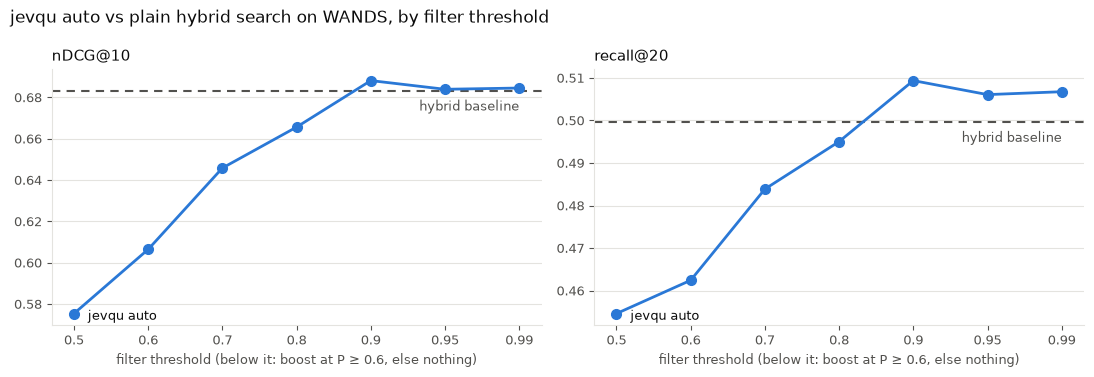

In [12]:
BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df"
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, key, base, title in [(axes[0], "ndcg10", np.mean(base_ndcg), "nDCG@10"),
                             (axes[1], "recall20", np.mean(base_rec), "recall@20")]:
    ys = [r[key] for r in curve]
    ax.axhline(base, color=MUTED, lw=1.5, ls=(0, (4, 3)))
    xs = range(len(THRESHOLDS))
    ax.plot(xs, ys, color=BLUE, lw=2, marker="o", ms=7)
    ax.annotate("hybrid baseline", (len(xs) - 1, base), xytext=(0, -14), textcoords="offset points",
                ha="right", color=MUTED, fontsize=9)
    ax.annotate("jevqu auto", (0, ys[0]), xytext=(10, -2), textcoords="offset points", va="center",
                color=INK, fontsize=9)
    ax.set_title(title, loc="left", color=INK, fontsize=11)
    ax.set_xlabel("filter threshold (below it: boost at P ≥ 0.6, else nothing)", color=MUTED, fontsize=9)
    ax.set_xticks(list(xs), [str(t) for t in THRESHOLDS])
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.tick_params(colors=MUTED, labelsize=9)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
fig.suptitle("jevqu auto vs plain hybrid search on WANDS, by filter threshold", x=0.01, ha="left", color=INK)
fig.tight_layout()
plt.show()

### How large should the boost be?

Boost-only mode (no filters) with three values of `boost_scale`. RRF-fused scores are small and close together, so a small boost moves little. Like the thresholds, this is a per-collection setting to fit, not a constant. The last line combines the default filter threshold with the largest boost; it is tuned on the evaluation queries themselves, so treat it as optimistic.

In [13]:
rows = ["| boost_scale | nDCG@10 | change vs baseline | queries changed |", "|---|---|---|---|"]
for s in (0.01, 0.05, 0.2):
    r = ranked("boost", Thresholds(boost_scale=s))
    nd, _ = scores(r)
    changed = np.mean([a != b for a, b in zip(r, runs[BASE])])
    rows.append(f"| {s} | {np.mean(nd):.4f} | {np.mean(nd) - np.mean(base_ndcg):+.4f} | {changed:.0%} |")
display(Markdown("\n".join(rows)))

tuned = scores(ranked("auto", Thresholds(boost_scale=0.2)))[0]
d, lo, hi = paired_bootstrap(base_ndcg, tuned)
print(f"jevqu auto with filter at 0.9 and boost_scale 0.2: nDCG@10 {np.mean(tuned):.4f}, "
      f"change {d:+.4f} (95% CI {lo:+.4f} to {hi:+.4f})")

| boost_scale | nDCG@10 | change vs baseline | queries changed |
|---|---|---|---|
| 0.01 | 0.6850 | +0.0019 | 66% |
| 0.05 | 0.6895 | +0.0065 | 70% |
| 0.2 | 0.7030 | +0.0200 | 70% |

jevqu auto with filter at 0.9 and boost_scale 0.2: nDCG@10 0.6995, change +0.0164 (95% CI +0.0038 to +0.0311)


## 9. How good does the classifier need to be?

Rerun query understanding with simulated classifiers of known quality (confidence floor 0.5, 0.7 and 0.9; the table reports the share of top guesses that came out right) and compare the three strategies. Point labels stay as they are. With a key, Jev is placed on the same axis.

nDCG@10 by classifier quality

| classifier | top guesses right | hybrid search | filter every guess | jevqu auto |
|---|---|---|---|---|
| simulated, floor 0.5 | 80% | 0.6831 | 0.5754 | 0.6881 |
| simulated, floor 0.7 | 88% | 0.6831 | 0.5876 | 0.6569 |
| simulated, floor 0.9 | 96% | 0.6831 | 0.6396 | 0.6396 |

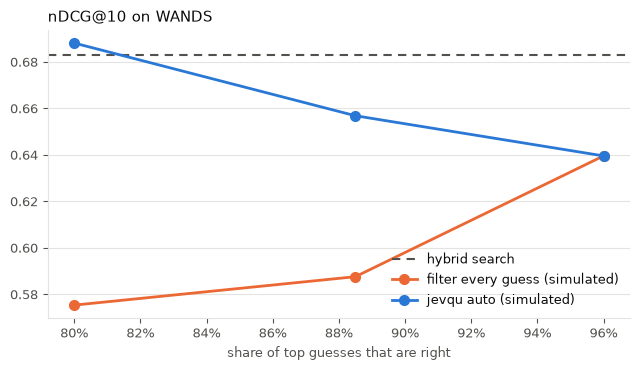

In [14]:
def measure(understood):
    return {"accuracy": np.mean([top_parent(u)[0] == intent(q["query_id"])[0] for u, q in zip(understood, evalq)]),
            NAIVE: np.mean(scores(ranked("filter", Thresholds(filter_above=0.5), understood))[0]),
            AUTO: np.mean(scores(ranked("auto", understood=understood))[0])}

quality = []
for floor in (0.5, 0.7, 0.9):
    u_sim = understand_all(SimulatedClassifier(conf_low=floor))
    quality.append({"name": f"simulated, floor {floor}", **measure(u_sim)})
sure = u_sim  # the 0.9-floor classifier: every query is filtered
real = {"name": f"Jev ({JEV_MODEL})", **measure(us)} if USE_JEV else None

rows = [f"| classifier | top guesses right | {BASE} | {NAIVE} | {AUTO} |", "|---|---|---|---|---|"]
rows += [f"| {q['name']} | {q['accuracy']:.0%} | {np.mean(base_ndcg):.4f} | {q[NAIVE]:.4f} | {q[AUTO]:.4f} |"
         for q in quality + ([real] if real else [])]
display(Markdown("nDCG@10 by classifier quality\n\n" + "\n".join(rows)))

ORANGE = "#eb6834"
fig, ax = plt.subplots(figsize=(6.5, 3.8))
acc = [q["accuracy"] for q in quality]
ax.axhline(np.mean(base_ndcg), color=MUTED, lw=1.5, ls=(0, (4, 3)), label=BASE)
ax.plot(acc, [q[NAIVE] for q in quality], color=ORANGE, lw=2, marker="o", ms=7, label=f"{NAIVE} (simulated)")
ax.plot(acc, [q[AUTO] for q in quality], color=BLUE, lw=2, marker="o", ms=7, label=f"{AUTO} (simulated)")
if real:
    ax.scatter([real["accuracy"]] * 2, [real[NAIVE], real[AUTO]], s=110, marker="D", color=[ORANGE, BLUE],
               edgecolor="white", linewidth=2, zorder=3, label="Jev (diamonds)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("share of top guesses that are right", color=MUTED, fontsize=9)
ax.set_title("nDCG@10 on WANDS", loc="left", color=INK, fontsize=11)
ax.legend(frameon=False, fontsize=9, labelcolor=INK, loc="lower right")
ax.grid(axis="y", color=GRID, lw=0.8)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)
fig.tight_layout()
plt.show()

### Why a better classifier doesn't help here

A more confident classifier filters more queries. Two things decide whether a filter pays off:

- **Was the guess right?** A confident wrong guess filters the relevant products out.
- **Do the relevant products sit in one category?** Many WANDS queries have exact matches in several categories ("bohemian" matches pillows, tapestries, rugs and a butter dish), and a filter on even the right category drops the rest.

The table splits the queries along both lines: with a key, by Jev's own filter decisions; without one, by the most confident simulated classifier (every query filtered).

In [15]:
analysed = us if USE_JEV else sure
with_filter = scores(ranked("auto", understood=analysed))[0]
target = [[c for c in intent(q["query_id"]) if c][-1] for q in evalq]
purity = [np.mean([t in (gold_classes(str(pid)) or ()) for pid in rel]) for t, rel in zip(target, relevant)]

def group(i):
    f = build_filter(analysed[i], tax, "auto")
    if f is None:
        return "no filter"
    if not all(c.match.value in intent(evalq[i]["query_id"]) for c in f.must):
        return "filter on a wrong category"
    return ("right category, 90%+ of relevant products in it" if purity[i] >= 0.9 else
            "right category, 50-90% in it" if purity[i] >= 0.5 else "right category, under 50% in it")

groups = defaultdict(list)
for i in range(len(evalq)):
    groups[group(i)].append(i)
rows = ["| queries | count | hybrid search | with jevqu | change |", "|---|---|---|---|---|"]
for name in ["right category, 90%+ of relevant products in it", "right category, 50-90% in it",
             "right category, under 50% in it", "filter on a wrong category", "no filter"]:
    idx = groups.get(name, [])
    if idx:
        b, f = np.mean([base_ndcg[i] for i in idx]), np.mean([with_filter[i] for i in idx])
        rows.append(f"| {name} | {len(idx)} | {b:.4f} | {f:.4f} | {f - b:+.4f} |")
display(Markdown("\n".join(rows)))

| queries | count | hybrid search | with jevqu | change |
|---|---|---|---|---|
| right category, 90%+ of relevant products in it | 115 | 0.6573 | 0.7109 | +0.0536 |
| right category, 50-90% in it | 41 | 0.6390 | 0.6601 | +0.0211 |
| right category, under 50% in it | 20 | 0.8101 | 0.7101 | -0.1000 |
| filter on a wrong category | 24 | 0.7756 | 0.2041 | -0.5714 |

## 10. Route, don't replace: Netflix's approach on the same data

Netflix's search team described their query understanding for semantic search in *From Tries to Transformers: Scaling Semantic Search* (Haystack EU 2026). Both systems put an understanding step in front of hybrid retrieval with filters and boosts, so the retrieval side compares directly:

| | Netflix | jevqu |
|---|---|---|
| Serving path | a router: trie and entity match (<10 ms), a Joint-BERT model for intents and slots (20–40 ms), an LLM only for complex natural language (100–1000 ms) | Jev on every query; exact facet matches as the fast path |
| Taxonomy | human-defined intents (FETCH, RECOMMENDATION, …) and slots (TITLE, PERSON, GENRE, …) | the catalog tree, or induced classes kept only if filtering by them improves nDCG |
| Filter or boost | decided by the slot type (an actor becomes a filter, a synopsis term a boost) | decided by confidence, with a page refill when a filter returns too few hits |
| Labels | human seed set, an LLM as judge to scale it, a consensus gate, regular retraining | Jev's labels, checked for calibration |
| Measured by | semantic-frame accuracy offline, A/B engagement online | nDCG@10 and recall lost against relevance labels |

Netflix's advice is "keep the LLM off the hot path: use it as a judge to scale labels and let a compact model serve traffic". Below, the same three-path router is built on WANDS:

- **fast path**: exact lookup of the whole query against catalog names (product classes such as "Beds" or "Area Rugs", and category names), which is how Netflix keeps its trie path to short, simple queries. Confidence is how pure that name is in the catalog, so an ambiguous name is boosted or ignored rather than filtered. A second variant matches a catalog name anywhere in the query, to show why the trie path stays narrow;
- **compact path**: a small classifier on query embeddings, trained on the labels the classifier wrote into the collection (product names read like queries). It reuses the embedding retrieval already computes;
- **advanced path**: the classifier itself, per query.

The router takes the fast path when a phrase matches, the compact path when its top guess has P ≥ 0.8, and the classifier otherwise.

In [16]:
def norm(s):  # lower-case words, crude singular: "Coffee Tables" -> "coffee table"
    return " ".join(w.rstrip("s") for w in re.findall(r"[a-z0-9]+", s.lower()))

by_class = defaultdict(Counter)
for p in products:
    g = gold_classes(p["product_id"])
    if g and p["product_class"].strip():
        by_class[p["product_class"]][g] += 1
phrases = {}
for name, votes in by_class.items():
    (a, b), n = votes.most_common(1)[0]
    total = sum(votes.values())
    phrases[norm(name)] = [(a, sum(v for (x, _), v in votes.items() if x == a) / total)] + ([(b, n / total)] if b else [])
for a, b in second:
    phrases.setdefault(norm(b), [(slug(a), 1.0), (slug(f"{a} {b}"), 1.0)])
for a in top:
    phrases.setdefault(norm(a), [(slug(a), 1.0)])

def fast_path(q, anywhere=False):  # whole query, or the longest phrase anywhere in it
    toks = norm(q).split()
    if not anywhere:
        hit = phrases.get(" ".join(toks))
        return Understanding(hit, {}, tax.version) if hit else None
    for n in range(min(5, len(toks)), 0, -1):
        for i in range(len(toks) - n + 1):
            hit = phrases.get(" ".join(toks[i:i + n]))
            if hit:
                return Understanding(hit, {}, tax.version)
    return None

t0 = time.perf_counter()
fast = [fast_path(q) for q in qtexts]
fast_ms = 1000 * (time.perf_counter() - t0) / len(qtexts)
fast_any = [fast_path(q, anywhere=True) for q in qtexts]
print(f"{len(phrases):,} catalog names; the whole query is one of them for {np.mean([f is not None for f in fast]):.0%} "
      f"of queries, one appears somewhere in {np.mean([f is not None for f in fast_any]):.0%}; {fast_ms:.3f} ms per query")

1,002 catalog names; the whole query is one of them for 0% of queries, one appears somewhere in 40%; 0.001 ms per query


In [17]:
# compact path: two small heads (parent, child) on product-name embeddings, labels from the collection's payload
name_cache = DATA / f"names_{SEED}_{N_QUERIES}_{N_PRODUCTS}_{MAX_EXACT_PER_QUERY}.npy"
if name_cache.exists():
    nvecs = np.load(name_cache)
else:
    nvecs = np.array(list(dense.embed([p["product_name"] for p in catalog], batch_size=64)))
    np.save(name_cache, nvecs)
stored = {pt.id: pt.payload for pt in client.scroll(COLLECTION, limit=len(points), with_payload=["classes", "class_probs"])[0]}
parents = {c.id for c in tax.level1()}
X1, y1, X2, y2 = [], [], [], []
for p, v in zip(catalog, nvecs):
    pl = stored[int(p["product_id"])]
    probs = pl.get("class_probs") or {}
    par = [c for c in pl.get("classes") or [] if c in parents]
    kid = [c for c in pl.get("classes") or [] if c not in parents]
    if par:
        X1.append(v); y1.append(max(par, key=probs.get))
    if kid:
        X2.append(v); y2.append(max(kid, key=probs.get))
head1 = LogisticRegression(max_iter=1000).fit(X1, y1)
head2 = LogisticRegression(max_iter=1000).fit(X2, y2)

def compact_path(vec):
    p1, p2 = head1.predict_proba([vec])[0], head2.predict_proba([vec])[0]
    return Understanding([(str(c), float(p)) for c, p in zip(head1.classes_, p1)] +
                         [(str(head2.classes_[p2.argmax()]), float(p2.max()))], {}, tax.version)

t0 = time.perf_counter()
compact = [compact_path(v) for v in qd]
predict_ms = 1000 * (time.perf_counter() - t0) / len(qd)
t0 = time.perf_counter()
for q in qtexts[:20]:
    list(dense.embed([q]))
embed_ms = 1000 * (time.perf_counter() - t0) / 20
print(f"trained on {len(y1):,} labeled points ({len(set(y1))} parent and {len(set(y2))} child classes); "
      f"{predict_ms:.2f} ms to predict + {embed_ms:.1f} ms to embed a query (shared with retrieval)")

trained on 9,608 labeled points (54 parent and 126 child classes); 0.15 ms to predict + 6.7 ms to embed a query (shared with retrieval)


In [18]:
# the advanced path's live speed and price, on fresh (uncached) requests
if USE_JEV:
    with tempfile.TemporaryDirectory() as d:
        live = Jev(cache_dir=d)
        lat = []
        for q in qtexts[:20]:
            t0 = time.perf_counter()
            understand_query(client, COLLECTION, q, live)
            lat.append(1000 * (time.perf_counter() - t0))
    adv_ms, adv_usd = float(np.median(lat)), sum(live.usage) / 20
    print(f"Jev, live: median {adv_ms:.0f} ms and ${adv_usd:.6f} per query "
          f"({len(tax.level1())} parent questions per request, children asked only under confident parents)")
else:
    adv_ms = adv_usd = None
    print("Simulated classifier: no latency or price to measure. Set OPENROUTER_API_KEY to measure Jev live.")

Simulated classifier: no latency or price to measure. Set OPENROUTER_API_KEY to measure Jev live.


In [19]:
ROUTE_CONF = 0.8
path, routed = [], []
for f, c, u in zip(fast, compact, us):
    if f is not None:
        path.append("fast"); routed.append(f)
    elif top_parent(c)[1] >= ROUTE_CONF:
        path.append("compact"); routed.append(c)
    else:
        path.append("advanced"); routed.append(u)
share = {k: path.count(k) / len(path) for k in ("fast", "compact", "advanced")}

def latency(p):  # the router tries the paths in order
    ms = fast_ms + (0 if p == "fast" else embed_ms + predict_ms)
    return ms + (adv_ms or 0) if p == "advanced" else ms

ROUTER = "Netflix-style router"
strategies = {
    "fast path only": (fast, fast_ms, 0.0),
    "fast path, name anywhere in the query": (fast_any, fast_ms, 0.0),
    "compact path only": (compact, embed_ms + predict_ms, 0.0),
    f"{ADV} on every query (jevqu auto)": (us, adv_ms, adv_usd),
    ROUTER: (routed, float(np.mean([latency(p) for p in path])) if adv_ms else None,
             share["advanced"] * adv_usd if adv_usd is not None else None),
}
rows = ["| strategy | nDCG@10 | change (95% CI) | recall@20 | understanding latency | cost per 1k queries |",
        "|---|---|---|---|---|---|",
        f"| {BASE} | {np.mean(base_ndcg):.4f} | | {np.mean(base_rec):.4f} | 0 ms | $0 |"]
router_rows = {}
for name, (understood, ms, usd) in strategies.items():
    r = ranked("auto", understood=[u or Understanding([], {}, tax.version) for u in understood])
    nd_s, rc_s = scores(r)
    d, lo, hi = paired_bootstrap(base_ndcg, nd_s)
    router_rows[name] = (d, lo, hi)
    ms_txt = f"{ms:.1f} ms" if ms is not None and ms < 10 else f"{ms:.0f} ms" if ms is not None else "n/a (simulated)"
    usd_txt = f"${1000 * usd:.3f}" if usd is not None else "n/a (simulated)"
    rows.append(f"| {name} | {np.mean(nd_s):.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {np.mean(rc_s):.4f} | {ms_txt} | {usd_txt} |")
display(Markdown("\n".join(rows)))
print(f"router: fast path {share['fast']:.0%}, compact path {share['compact']:.0%}, {ADV} {share['advanced']:.0%} of queries")

| strategy | nDCG@10 | change (95% CI) | recall@20 | understanding latency | cost per 1k queries |
|---|---|---|---|---|---|
| hybrid search | 0.6831 | | 0.4995 | 0 ms | $0 |
| fast path only | 0.6830 | -0.0000 (-0.0001 to +0.0000) | 0.4996 | 0.0 ms | $0.000 |
| fast path, name anywhere in the query | 0.6330 | -0.0501 (-0.0769 to -0.0245) | 0.4718 | 0.0 ms | $0.000 |
| compact path only | 0.6787 | -0.0044 (-0.0179 to +0.0051) | 0.4967 | 6.9 ms | $0.000 |
| simulated classifier on every query (jevqu auto) | 0.6881 | +0.0051 (-0.0055 to +0.0176) | 0.5094 | n/a (simulated) | n/a (simulated) |
| Netflix-style router | 0.6824 | -0.0007 (-0.0176 to +0.0158) | 0.5057 | n/a (simulated) | n/a (simulated) |

router: fast path 0%, compact path 39%, simulated classifier 60% of queries


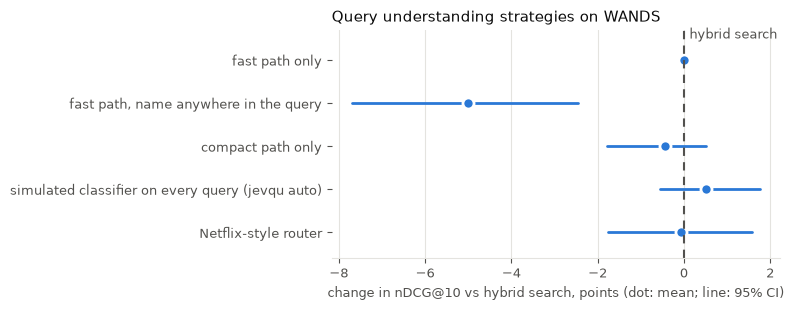

In [20]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ys = list(range(len(router_rows)))[::-1]
for y, (name, (d, lo, hi)) in zip(ys, router_rows.items()):
    ax.plot([100 * lo, 100 * hi], [y, y], color=BLUE, lw=2, solid_capstyle="round")
    ax.plot(100 * d, y, "o", color=BLUE, ms=8, markeredgecolor="white", markeredgewidth=2)
ax.axvline(0, color=MUTED, lw=1.5, ls=(0, (4, 3)))
ax.annotate("hybrid search", (0, len(ys) - 0.5), xytext=(4, 0), textcoords="offset points", color=MUTED, fontsize=9)
ax.set_yticks(ys, list(router_rows))
ax.set_ylim(-0.6, len(ys) - 0.3)
ax.set_xlabel("change in nDCG@10 vs hybrid search, points (dot: mean; line: 95% CI)", color=MUTED, fontsize=9)
ax.set_title("Query understanding strategies on WANDS", loc="left", color=INK, fontsize=11)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(GRID)
fig.tight_layout()
plt.show()

## 11. Two queries up close

The query jevqu helped most, and the query where filtering every guess did the most damage compared with jevqu's gating. ✓ marks a product WANDS judges an exact match.

In [21]:
nd = {name: scores(r)[0] for name, r in runs.items()}
names = {int(p["product_id"]): p["product_name"] for p in catalog}

def show(i, strategies):
    explain(i)
    for s in strategies:
        print(f"   {s}: nDCG@10 {nd[s][i]:.2f}")
        for pid in runs[s][i][:5]:
            print("      ", "✓" if pid in relevant[i] else "·", names[pid][:70])
    print()

show(int(np.argmax(np.array(nd[AUTO]) - nd[BASE])), [BASE, AUTO])
show(int(np.argmax(np.array(nd[AUTO]) - nd[NAIVE])), [BASE, NAIVE, AUTO])

"wainscoting ideas"   (intended: Home Improvement / Flooring, Walls & Ceiling)
   P=0.93  filter  Home Improvement / Flooring, Walls & Ceiling
   P=0.88  boost   Home Improvement
   P=0.02  ignore  Accommodations
   Qdrant filter: ['home-improvement-flooring-walls-ceiling']
   formula boost: [('home-improvement', 0.0088)]
   hybrid search: nDCG@10 0.33
       · markovich 5 drawer combo dresser
       · metaphor drum coffee table
       ✓ 3/4 in . x 3 in . x 8 ft. mdf wainscot base moulding
       · zen element birdbath
       ✓ peel and stick instant panel wainscoting 28 '' h x 28 '' w x 0.3 '' d 
   jevqu auto: nDCG@10 1.00
       ✓ 3/4 in . x 3 in . x 8 ft. mdf wainscot base moulding
       ✓ peel and stick instant panel wainscoting 28 '' h x 28 '' w x 0.3 '' d 
       ✓ colorado 36 '' x 24 '' metal wall paneling
       ✓ ashford 20 '' h x 20 '' w x 1/2 '' d molded classic wainscot wall pane
       ✓ ashford 8 '' h x 8 '' w x 1/2 '' d molded classic wainscot wall panel

"bohemian"   

## 12. Takeaways

Generated from this run's numbers, so they hold whether the notebook ran offline or with Jev.

In [22]:
pts = lambda x: f"{100 * x:+.1f}"
any_nd = scores(ranked("auto", understood=[u or Understanding([], {}, tax.version) for u in fast_any]))[0]
worst = max((i for i, f in enumerate(fast_any) if f), key=lambda i: base_ndcg[i] - any_nd[i])
dn = paired_bootstrap(base_ndcg, scores(runs[NAIVE])[0])
da = paired_bootstrap(base_ndcg, scores(runs[AUTO])[0])
def split(name):
    idx = groups.get(name, [])
    return len(idx), (np.mean([with_filter[i] - base_ndcg[i] for i in idx]) if idx else 0.0)
right_n, right_d = split("right category, 90%+ of relevant products in it")
wrong_n, wrong_d = split("filter on a wrong category")
best = max(curve, key=lambda r: r["ndcg10"])
dr = router_rows[ROUTER]
n_bare = sum(f is not None for f in fast)
bare = "None" if n_bare == 0 else f"Only {n_bare}"
speed = (f", in {strategies[ROUTER][1]:.0f} ms on average instead of {strategies[list(strategies)[2]][1]:.0f} ms "
         f"and ${1000 * strategies[ROUTER][2]:.3f} instead of ${1000 * adv_usd:.3f} per 1k queries") if adv_ms else ""
display(Markdown("\n".join([
    f"1. **Gating is what makes category filters safe.** Filtering on every guess of the {ADV} changed nDCG@10 by "
    f"{pts(dn[0])} points (95% CI {pts(dn[1])} to {pts(dn[2])}). Behind jevqu's gates the change was {pts(da[0])} "
    f"(CI {pts(da[1])} to {pts(da[2])}).",
    f"2. **A right filter helps; a wrong one wipes the query out.** In section 9's split, a filter on the right category "
    f"of a single-category query changed nDCG@10 by {pts(right_d)} points ({right_n} queries); a filter on a wrong "
    f"category changed it by {pts(wrong_d)} ({wrong_n} queries).",
    f"3. **The threshold is a per-collection setting.** Here the best filter threshold was {best['threshold']} "
    f"({pts(best['ndcg_gain'])} points, recall@20 lost {best['recall_loss']:.3f}).",
    f"4. **Route, don't replace.** The Netflix-style router answered {share['fast']:.0%} of queries with the phrase "
    f"lookup, {share['compact']:.0%} with the compact model and {share['advanced']:.0%} with the {ADV}, for "
    f"{pts(dr[0])} points (CI {pts(dr[1])} to {pts(dr[2])}){speed}. {bare} of the {len(qtexts)} "
    f"queries is a bare catalog name, so the trie path has little to do on WANDS, unlike the title and "
    f"name searches (\"bloodline\", \"wes\") in Netflix's slides.",
    f"5. **Keep the trie path narrow.** Matching a catalog name anywhere in the query and acting on it changed nDCG@10 by "
    f"{pts(router_rows['fast path, name anywhere in the query'][0])} points. Worst case: \"{qtexts[worst]}\" matched "
    f"*{label_of[fast_any[worst].classes[-1][0]]}* and fell from {base_ndcg[worst]:.2f} to {any_nd[worst]:.2f}.",
])))

1. **Gating is what makes category filters safe.** Filtering on every guess of the simulated classifier changed nDCG@10 by -10.8 points (95% CI -15.1 to -6.5). Behind jevqu's gates the change was +0.5 (CI -0.6 to +1.8).
2. **A right filter helps; a wrong one wipes the query out.** In section 9's split, a filter on the right category of a single-category query changed nDCG@10 by +5.4 points (115 queries); a filter on a wrong category changed it by -57.1 (24 queries).
3. **The threshold is a per-collection setting.** Here the best filter threshold was 0.9 (+0.5 points, recall@20 lost 0.000).
4. **Route, don't replace.** The Netflix-style router answered 0% of queries with the phrase lookup, 39% with the compact model and 60% with the simulated classifier, for -0.1 points (CI -1.8 to +1.6). Only 1 of the 200 queries is a bare catalog name, so the trie path has little to do on WANDS, unlike the title and name searches ("bloodline", "wes") in Netflix's slides.
5. **Keep the trie path narrow.** Matching a catalog name anywhere in the query and acting on it changed nDCG@10 by -5.0 points. Worst case: "luau string lights" matched *Lighting / Outdoor Lighting* and fell from 1.00 to 0.00.

**What this does not show.** Offline, the simulated classifier stands in for Jev and picks its confidence without reading the query, so it cannot know that "bohemian" spans five categories; rerun with `OPENROUTER_API_KEY` set for Jev's numbers. In either mode, thresholds here are tuned on the evaluation queries themselves (fit them on held-out queries before shipping), and relevance comes from offline labels: Netflix validated theirs with an A/B test and a holdback, which is the step after this one.

## Appendix: induce the taxonomy instead (needs an OpenRouter key and `JEVQU_INDUCE=1`)

Most collections have no clean category tree. `create_query_understanding` clusters a sample of points, names candidate classes, and keeps a class only if:

- it covers between 0.5% and 40% of points (so payload-filtered search stays fast),
- enough training queries ask for it,
- it doesn't duplicate a facet, and
- filtering by it improves nDCG@10 on the queries that ask for it (bootstrap lower bound above zero).

The training queries here are WANDS queries outside the evaluation set. Their relevant products are mostly outside the 10k-point collection, so few classes will clear the last gate. For a real induction run, build the collection around the training queries too.

In [23]:
if USE_JEV and os.environ.get("JEVQU_INDUCE"):  # opt-in: ~5k sequential Jev requests, roughly 40 minutes
    train = [q for q in usable if q not in evalq][:100]
    induced, report = create_query_understanding(
        client, COLLECTION, classifier, sample=1000, queries=[q["query"] for q in train],
        relevant=[{int(pid) for pid in exact[q["query_id"]] if pid in keep} for q in train],
        embed=lambda texts: np.array(list(dense.embed(texts))))
    print(f"kept {sum(r['kept'] for r in report)} of {len(report)} candidate classes")
    for r in report[:15]:
        print(f"   {'kept' if r['kept'] else '    '}  {r['id'][:40]:40}  coverage {r['coverage']:.1%}  "
              f"demand {r['demand']}  nDCG gain {r['value'][0]:+.3f}")
else:
    print("Skipped: set OPENROUTER_API_KEY and JEVQU_INDUCE=1 to induce a taxonomy (~5k sequential Jev requests).")

Skipped: set OPENROUTER_API_KEY and JEVQU_INDUCE=1 to induce a taxonomy (~5k sequential Jev requests).
